In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from classes import Problem, Boat, Trip
import seaborn as sns
import scikit_posthocs as sp

ModuleNotFoundError: No module named 'gurobipy'

In [ ]:
records = []
with open("final_heur_output.txt", "r") as f:
    for line in f:
        if line.strip():
            d = ast.literal_eval(line.strip())
            # d = eval(line.strip())
            d['solution_log'] = str(d['solution_log'])
            records.append(d)

# --- Step 2: Build DataFrame ---
df_orig = pd.DataFrame(records)
display(df_orig)

,problem_id,method,num_stations,num_boats,num_iter,best_obj,best_solution,solution_log
0,34_0,2,40,1,15,76.148150,"[[[12, 12], [12, 289, 290, 267, 268, 248, 247,...","[(33.298003911972046, 88.50766510577604, 88.50..."
1,34_2,2,40,1,16,80.629282,"[[[12, 294, 293, 282, 281, 274, 273, 270, 269,...","[(41.50418734550476, 90.09986282506671, 90.099..."
2,34_3,2,40,1,15,90.541979,"[[[12, 301, 302, 298, 297, 12], [12, 290, 289,...","[(38.80500841140747, 103.55554843926281, 103.5..."
3,34_4,2,40,1,16,76.349836,"[[[12, 294, 293, 282, 281, 274, 273, 272, 271,...","[(38.87684917449951, 82.89006869070383, 82.890..."
4,34_9,2,40,1,19,69.568718,"[[[12, 12], [12, 296, 295, 263, 264, 266, 265,...","[(39.45483994483948, 82.01173969835386, 82.011..."
...,...,...,...,...,...,...,...,...
200,34_5,9,40,1,5,76.520549,"[[[12, 300, 299, 12], [12, 282, 281, 274, 273,...","[(119.47571873664856, 76.52054940540049, 76.52..."
201,34_6,9,40,1,6,68.937551,"[[[12, 282, 281, 274, 273, 272, 271, 241, 242,...","[(119.89362144470215, 68.93755100325224, 68.93..."
202,34_7,9,40,1,5,72.007520,"[[[12, 12], [12, 287, 288, 263, 264, 261, 262,...","[(125.91270184516907, 72.00751973135404, 72.00..."
203,34_8,9,40,1,5,68.366628,"[[[12, 12], [12, 298, 297, 284, 283, 277, 278,...","[(147.1822817325592, 68.47090820025788, 68.470..."


In [ ]:
import glob
import numpy as np
for prob_id in range(25, 36):
    filename = glob.glob(f"better_test_problems/test_problem{prob_id:02d}*")[0]
    with open(filename, "r") as f:
        result = f.read()
    split = result.split('; ')
    s = np.array(eval(split[0]))
    p = np.array(eval(split[1]))
    b = int(split[2])
    c = np.array(eval(split[3]))
    t = int(split[4])
    w = int(split[5])

60
60
60
30
30
30
30
30
30
30
30


1.0657070240010313

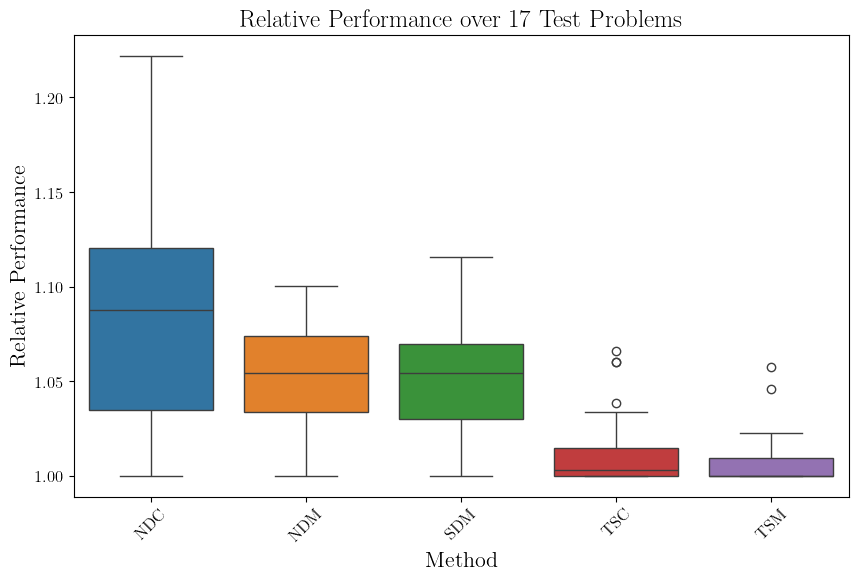

In [ ]:
import pandas as pd
import numpy as np
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare
import seaborn as sns
import matplotlib.pyplot as plt

# Example: df with columns ['prob_id', 'method', 'best_obj']
# df = pd.read_csv("your_results.csv")

# 1️⃣ Pivot so each row = problem, each column = method
df_filt = df_orig.copy()
# df_filt = df[df['method'] <= 10][df['method'] > 0][df['best_obj'] < 10000]
df_filt['method'] = df_filt['method'].map({0: "NDS1", 1: "NDS", 2: "NDM", 3: "SDM", 4: "NDC", 5: "SDS", 6: "TSM", 7: "TSS", 8: "SA", 9: "TSC", 10: "ACO"})
pivot = df_filt.pivot(index='problem_id', columns='method', values='best_obj')

# 2️⃣ Rank algorithms per problem (lower objective = better)
ranks = pivot.rank(axis=1, method='average')

# 3️⃣ Friedman test
# stat, p = friedmanchisquare(*[ranks[col] for col in ranks.columns])
# print(f"Friedman test statistic = {stat:.3f}, p-value = {p:.5f}")

# if p < 0.05:
#     print("→ Significant differences detected between algorithms.")
# else:
#     print("→ No significant differences detected between algorithms.")

# # 4️⃣ Post-hoc Nemenyi test
# nemenyi = sp.posthoc_nemenyi_friedman(ranks)
# print("\nPairwise p-values (Nemenyi test):")
# print(nemenyi.round(4))

# # 5️⃣ Optional: visualize post-hoc matrix as heatmap
# plt.figure(figsize=(8,6))
# sns.heatmap(nemenyi, annot=True, cmap='coolwarm', fmt=".3f")
# plt.title('Post-hoc Nemenyi Test (p-values)')
# plt.show()

# 6️⃣ Relative performance boxplot (optional visualization)
relative = pivot.div(pivot.min(axis=1), axis=0)
# font = {'family': 'sans-serif', 
#         'weight' : 'bold',
#         'size'   : 36}

plt.rcParams.update({
    "text.usetex": True,     # enables LaTeX rendering
    "font.family": "serif",    # use a serif font
    "font.serif": ["Computer Modern"]  # closest to Overleaf
})
display(relative['TSC'].max())
# plt.rc('font', **font)
plt.figure(figsize=(10, 6))
sns.boxplot(data=relative) #, order=['NDM', 'NDS', 'NDC', 'SDM', 'SDS', 'TSM', 'TSS', 'TSC', 'SA', 'ACO'])
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Method", fontsize=16)
plt.ylabel("Relative Performance", fontsize=16)
# plt.ylabel("Objective / Best Objective", fontsize=18)
plt.title("Relative Performance over 17 Test Problems", fontsize=18)
plt.show()


(array([7., 1., 1., 1., 0., 2., 2., 1., 4., 1.]),
 array([ 5.16009549,  8.24814311, 11.33619072, 14.42423834, 17.51228595,
        20.60033357, 23.68838118, 26.7764288 , 29.86447641, 32.95252403,
        36.04057164]),
 <BarContainer object of 10 artists>)

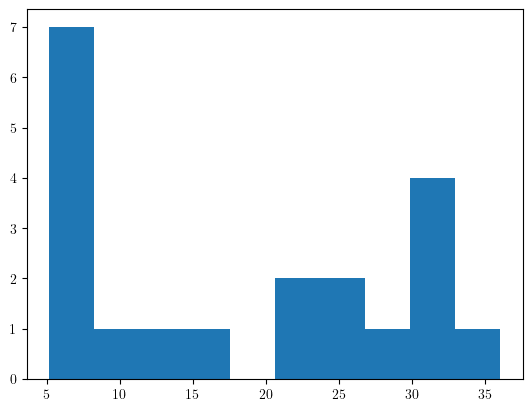

In [ ]:
records = []
with open("final_mip_output.txt", "r") as f:
    for line in f:
        if line.strip():
            d = ast.literal_eval(line.strip())
            # d = eval(line.strip())
            # d['solution_log'] = str(d['solution_log'])
            records.append(d)

# --- Step 2: Build DataFrame ---
df_mip_orig = pd.DataFrame(records)
df_mip_orig["bound_gap"] = (df_mip_orig["best_obj"]-df_mip_orig["best_bound"])/df_mip_orig["best_bound"]*100
# display(df_mip_orig[df_mip_orig['problem_id'].isin([28, 29, 31])])
plt.hist(df_mip_orig["bound_gap"])

7.266687546646226


(array([4., 4., 5., 4., 4., 7., 3., 3., 5., 2.]),
 array([-9.12985507, -8.07809237, -7.02632966, -5.97456695, -4.92280425,
        -3.87104154, -2.81927884, -1.76751613, -0.71575343,  0.33600928,
         1.38777199]),
 <BarContainer object of 10 artists>)

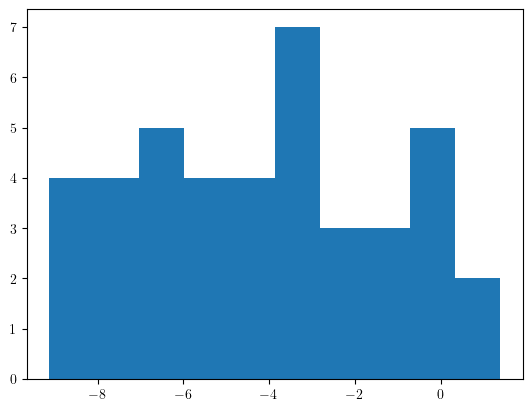

In [ ]:
df_heur = df_orig.copy()
df_mip = df_mip_orig.copy()
df_mip['method'] = -1
df = pd.concat([df_heur, df_mip[df_mip['best_obj'] > 0]])
df['method'] = df['method'].map({-1: 'MIP', 2: "NDM", 3: "SDM", 4: "NDC", 6: "TSM", 9: "TSC"})

# compute % difference vs MIP per problem
mip = df[df['method'] == 'NDM'][['problem_id', 'best_obj']].rename(columns={'best_obj': 'mip_obj'}).copy()
mip['mip_obj'] = pd.to_numeric(mip['mip_obj'], errors='coerce')

df_comp = df.copy()
df_comp['best_obj'] = pd.to_numeric(df_comp['best_obj'], errors='coerce')

df_comp = df_comp.merge(mip, on='problem_id', how='left')
df_comp['pct_vs_MIP'] = (df_comp['best_obj'] - df_comp['mip_obj']) / df_comp['mip_obj'] * 100
# df_comp = df_comp.dropna()

# show results (exclude rows where MIP value is missing)
df_comp = df_comp[['problem_id', 'method', 'best_obj', 'mip_obj', 'pct_vs_MIP']].sort_values(['problem_id', 'method'])
print(df_comp[df_comp['mip_obj'] > 0][df_comp['method'] == 'SDM']['pct_vs_MIP'].max())
plt.hist(df_comp[df_comp['mip_obj'] > 0][df_comp['method'] == 'TSM']['pct_vs_MIP'])

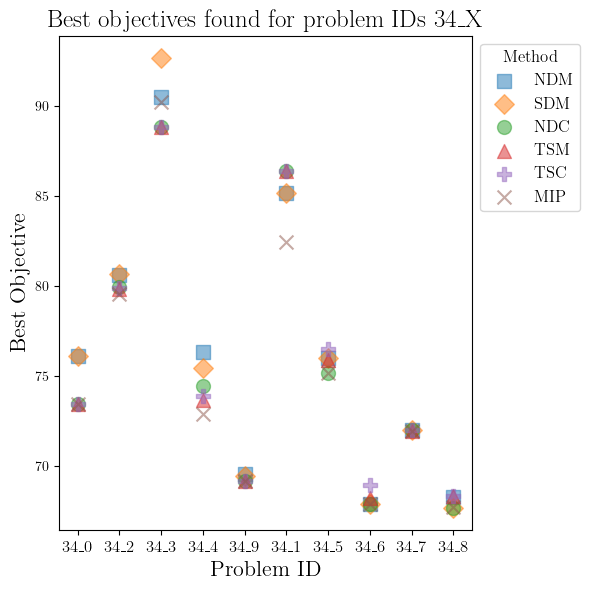

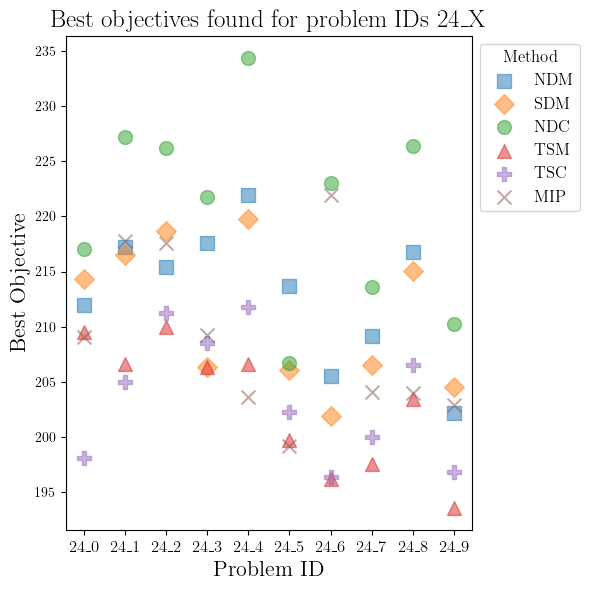

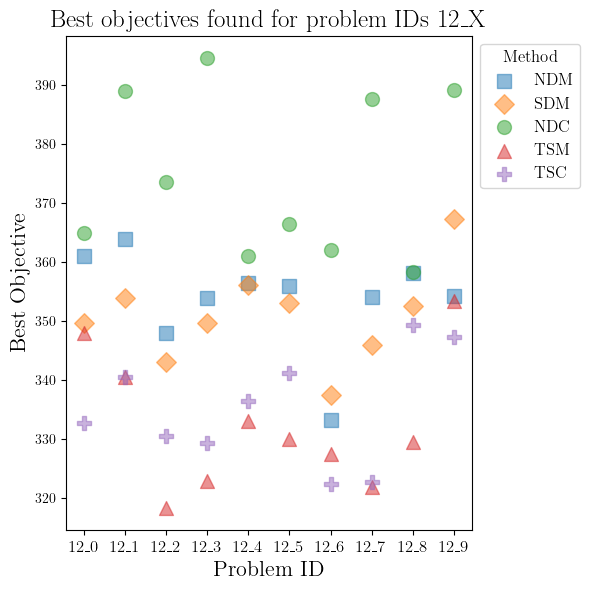

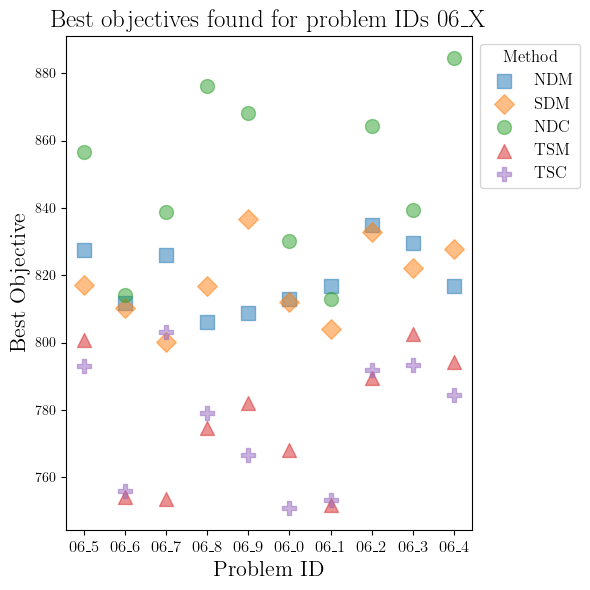

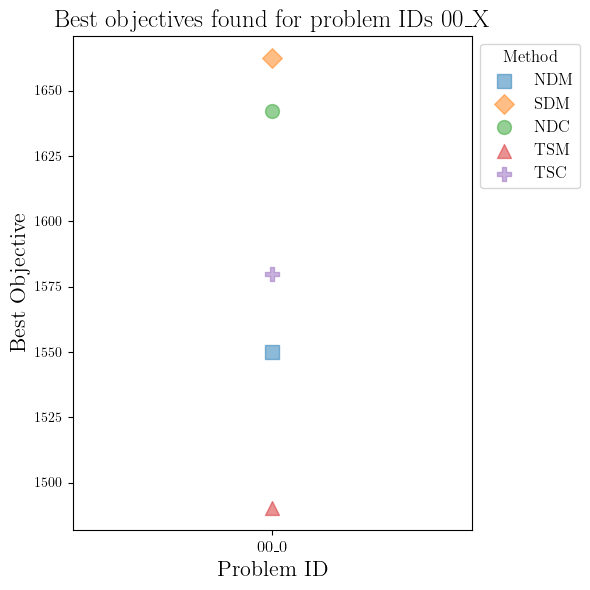

In [ ]:
df_heur = df_orig.copy()
df_mip = df_mip_orig.copy()
df_mip['method'] = -1
df = pd.concat([df_heur, df_mip[df_mip['best_obj'] > 0]])
df['method'] = df['method'].map({-1: 'MIP', 2: "NDM", 3: "SDM", 4: "NDC", 6: "TSM", 9: "TSC"})

markers = {
    'NDC': 'o',   # circle
    'NDM': 's',   # square
    'TSM': '^',   # triangle up
    'TSC': 'P',   # diamond
    'SDM': 'D',   # x
    'MIP': 'x'
}
plt.rcParams.update({
    "text.usetex": True,     # enables LaTeX rendering
    "font.family": "serif",    # use a serif font
    "font.serif": ["Computer Modern"]  # closest to Overleaf
})
# for pid in [['34', '24'], ['12', '06']]:#, ['00']]:
for pid in ['34', '24', '12', '06', '00']:
    plt.figure(figsize=(6,6))
    group = df[df['problem_id'].astype(str).str.startswith(pid)] # | df['problem_id'].astype(str).str.startswith(pid[1])]
    
    # loop through each method only once
    for method in group["method"].unique():
        if method == 'MIP':
            s = 100
        else:
            s = 100
        df0 = group[group["method"] == method]
        plt.scatter(
            df0["problem_id"], df0["best_obj"],
            marker=markers.get(str(method), 'o'),   # color by method
            label=str(method),                       # add label for legend
            alpha=0.5,
            s=s
        )
    
    plt.title(f"Best objectives found for problem IDs {pid}_X", fontsize=18)
    plt.xlabel("Problem ID", fontsize=16)
    plt.ylabel("Best Objective", fontsize=16)
    plt.xticks(fontsize=12)
    plt.xticks(fontsize=12)
    plt.legend(title="Method", loc="upper left", ncol=1, fontsize=12, title_fontsize=12, bbox_to_anchor=(1, 1))
#     plt.legend(, loc='upper left', borderaxespad=0.)
# plt.tight_layout()
    plt.tight_layout()
    plt.show()


In [ ]:
df = df_orig.copy()
df = df[df['problem_id'] != '00_0']#[df['num_stations'] > 40]

pivot = df.pivot(index='problem_id', columns='method', values='best_obj').dropna()

# stat, p_value = friedmanchisquare(*[pivot[col] for col in pivot.columns])
# print(f"Friedman test statistic: {stat:.4f}")
# print(f"p-value: {p_value:.4e}")

# === RANKS ===
ranks = pivot.rank(axis=1, method='average')
print(ranks[3].value_counts())
avg_ranks = ranks.mean().sort_values()
print("\nAverage ranks (lower = better):")
print(avg_ranks)

3
3.0    20
4.0    10
2.0     3
1.5     2
5.0     2
3.5     2
4.5     1
Name: count, dtype: int64

Average ranks (lower = better):
method
6    1.5750
9    2.1125
3    3.2625
2    3.7500
4    4.3000
dtype: float64
